In [1]:
import typing as t

import numpy as np
import polars as pl

from src.config.constants import Product
from src.research import (
    ADFResult,
    AnalysisResult,
    MeanReversionTestResults,
    OrderbookAnalysisResult,
    Plots,
    SubsampledRegressionResults,
    TradesAnalysisResult,
    display_plots,
    run_analysis,
    run_mean_reversion_test,
)

VELVETFRUIT_EXTRACT: t.Final[Product] = Product.VELVETFRUIT_EXTRACT
ROUND: t.Final[int] = 3
DAY: t.Final[int] = 0

analysis_result: t.Final[AnalysisResult] = run_analysis(ROUND, DAY, VELVETFRUIT_EXTRACT)
orderbook_analysis: t.Final[OrderbookAnalysisResult] = (
    analysis_result.orderbook_analysis_result
)
trades_analysis: t.Final[TradesAnalysisResult] = analysis_result.trades_analysis_result
plots: t.Final[Plots] = analysis_result.plots

# Orderbook Analysis

In [2]:
orderbook_data: t.Final[pl.DataFrame] = orderbook_analysis.orderbook_data
orderbook_features_data: t.Final[pl.DataFrame] = (
    orderbook_analysis.orderbook_features_data
)
orderbook_stats: t.Final[pl.DataFrame] = orderbook_analysis.orderbook_stats
orderbook_corrs: t.Final[pl.DataFrame] = orderbook_analysis.orderbook_corrs

orderbook_data

timestamp,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,spread,imbalance,midprice_dev,log_returns,future_log_returns,microprice,microprice_dev,depth
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,f64,f64,f64,f64,f64,f64,i64
0,5247,67,null,null,null,null,5253,67,null,null,null,null,5250.0,6,0.0,3.48975,null,0.000095,5250.0,0.0,134
100,5248,69,null,null,null,null,5253,23,5254,46,null,null,5250.5,5,0.0,3.98975,0.000095,0.0,5251.75,1.25,92
200,5248,20,5247,40,null,null,5253,60,null,null,null,null,5250.5,5,0.0,3.98975,0.0,0.0,5249.25,-1.25,80
300,5248,24,5247,40,null,null,5253,64,null,null,null,null,5250.5,5,0.0,3.98975,0.0,0.0,5249.363636,-1.136364,88
400,5248,25,5247,37,null,null,5253,62,null,null,null,null,5250.5,5,0.0,3.98975,0.0,-0.00019,5249.436782,-1.063218,87
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
999500,5242,63,null,null,null,null,5247,19,5248,44,null,null,5244.5,5,0.0,-2.01025,0.000191,-0.000095,5245.841463,1.341463,82
999600,5243,56,null,null,null,null,5245,11,5248,25,5249,31,5244.0,2,-0.089431,-2.51025,-0.000095,0.000286,5244.671642,0.671642,67
999700,5243,20,5242,37,null,null,5248,57,null,null,null,null,5245.5,5,0.0,-1.01025,0.000286,0.0,5244.298701,-1.201299,77


In [3]:
orderbook_features_data

timestamp,mid_price,midprice_dev,spread,imbalance,log_returns,future_log_returns,microprice,microprice_dev,depth
i64,f64,f64,i64,f64,f64,f64,f64,f64,i64
0,5250.0,3.48975,6,0.0,null,0.000095,5250.0,0.0,134
100,5250.5,3.98975,5,0.0,0.000095,0.0,5251.75,1.25,92
200,5250.5,3.98975,5,0.0,0.0,0.0,5249.25,-1.25,80
300,5250.5,3.98975,5,0.0,0.0,0.0,5249.363636,-1.136364,88
400,5250.5,3.98975,5,0.0,0.0,-0.00019,5249.436782,-1.063218,87
…,…,…,…,…,…,…,…,…,…
999500,5244.5,-2.01025,5,0.0,0.000191,-0.000095,5245.841463,1.341463,82
999600,5244.0,-2.51025,2,-0.089431,-0.000095,0.000286,5244.671642,0.671642,67
999700,5245.5,-1.01025,5,0.0,0.000286,0.0,5244.298701,-1.201299,77


In [4]:
orderbook_stats

statistic,mid_price,midprice_dev,spread,imbalance,log_returns,future_log_returns,microprice,microprice_dev,depth
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",10000.0,10000.0,10000.0,10000.0,9999.0,9999.0,10000.0,10000.0,10000.0
"""null_count""",0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
"""mean""",5246.51025,-2.6921e-13,4.9935,-0.00003,-1.1436e-7,-1.1436e-7,5246.503314,-0.006936,75.7374
"""std""",13.677795,13.677795,0.839004,0.019488,0.000214,0.000214,13.67946,0.928354,28.843561
"""min""",5216.5,-30.01025,1.0,-0.168317,-0.001046,-0.001046,5215.458333,-1.74359,20.0
"""25%""",5236.5,-10.01025,5.0,0.0,-0.00019,-0.00019,5236.5,-1.044304,50.0
"""50%""",5244.5,-2.01025,5.0,0.0,0.0,0.0,5244.670213,0.0,78.0
"""75%""",5255.5,8.98975,5.0,0.0,0.00019,0.00019,5255.27907,1.013514,90.0
"""max""",5284.5,37.98975,6.0,0.137615,0.000956,0.000956,5285.910256,1.5625,150.0


In [5]:
orderbook_corrs

imb_corr,micro_corr
f64,f64
-0.314267,0.22652


# Trades Analysis

In [6]:
trades_data: t.Final[pl.DataFrame] = trades_analysis.trades_data
time_interval_stats: t.Final[pl.DataFrame] = trades_analysis.time_interval_stats
quantities_stats: t.Final[pl.DataFrame] = trades_analysis.quantities_stats
order_side_stats: t.Final[pl.DataFrame] = trades_analysis.order_side_stats
trade_price_streaks_stats: t.Final[pl.DataFrame] = (
    trades_analysis.trade_price_streaks_stats
)

trades_data

timestamp,price,quantity,best_bid,best_ask,mid_price,time_since_prev_trade,time_until_next_trade,mid_price_dev,side_heur
i64,f64,i64,i64,i64,f64,i64,i64,f64,str
2500,5250.0,4,5245,5250,5247.5,null,2700,2.5,"""BUY_ORDER"""
5200,5236.0,3,5236,5241,5238.5,2700,300,-2.5,"""SELL_ORDER"""
5500,5241.0,8,5236,5241,5238.5,300,3800,2.5,"""BUY_ORDER"""
9300,5229.0,6,5229,5231,5230.0,3800,2600,-1.0,"""SELL_ORDER"""
11900,5237.0,4,5232,5237,5234.5,2600,2100,2.5,"""BUY_ORDER"""
…,…,…,…,…,…,…,…,…,…
985800,5239.0,5,5239,5244,5241.5,900,1100,-2.5,"""SELL_ORDER"""
986900,5250.0,8,5245,5250,5247.5,1100,2300,2.5,"""BUY_ORDER"""
989200,5247.0,8,5242,5247,5244.5,2300,700,2.5,"""BUY_ORDER"""


In [7]:
time_interval_stats

time_since_prev_mean,time_since_prev_var,time_since_prev_std,time_until_next_mean,time_until_next_var,time_until_next_std
f64,f64,f64,f64,f64,f64
2226.576577,4.3134e6,2076.867321,2226.576577,4.3134e6,2076.867321


In [8]:
quantities_stats

qty_mean,qty_median,qty_mode,qty_var,qty_std
f64,f64,i64,f64,f64
6.042697,6.0,7,5.058984,2.249218


In [9]:
order_side_stats

total_orders,buy_orders,buy_order_rate,sell_orders,sell_order_rate
i64,i64,f64,i64,f64
445,252,0.566292,193,0.433708


In [10]:
trade_price_streaks_stats

price,streak_length
f64,u32
5247.0,1
5237.0,1
5269.0,2
5229.0,1
5232.0,1
…,…
5238.0,1
5265.0,1
5244.0,1


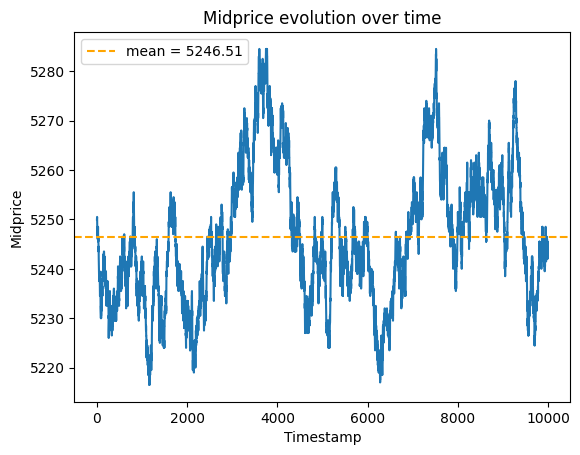

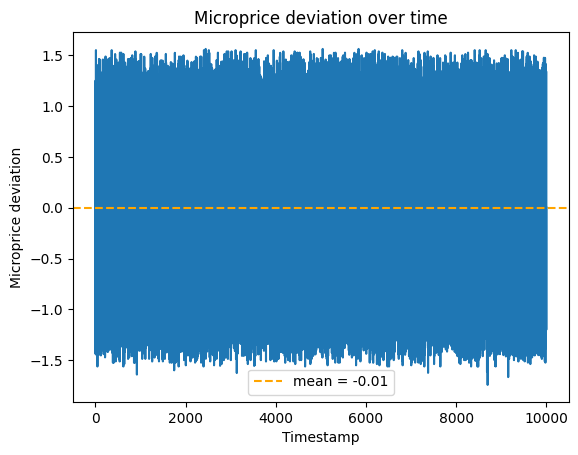

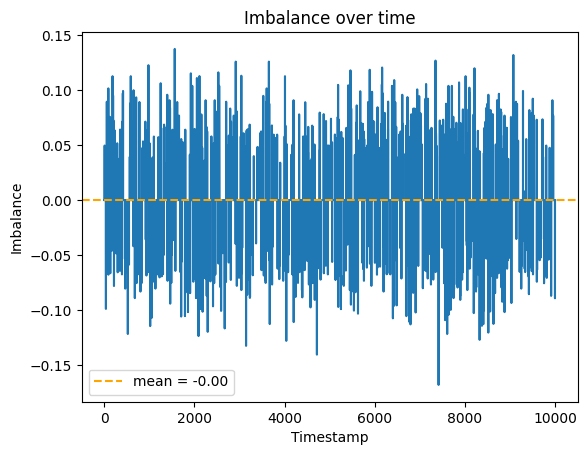

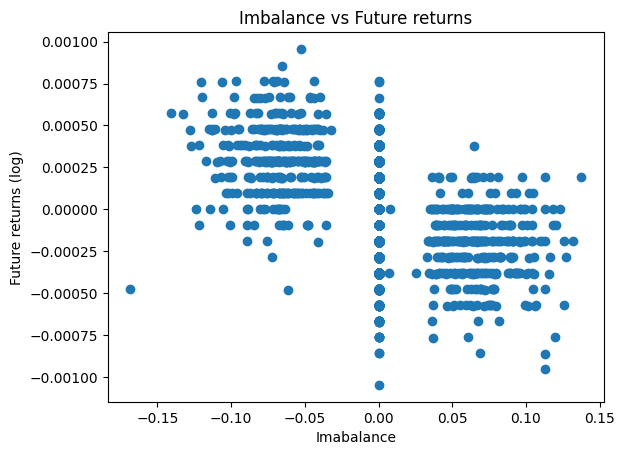

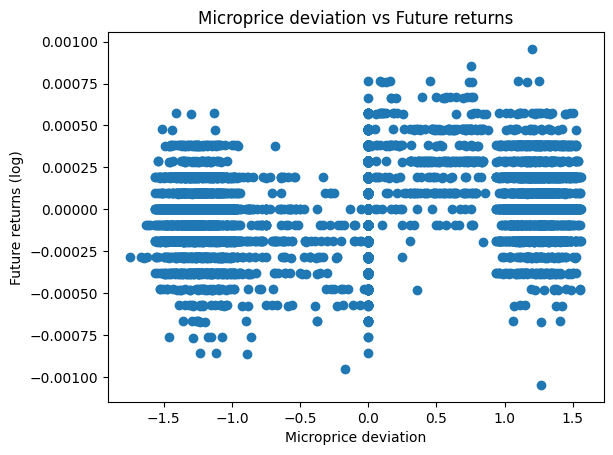

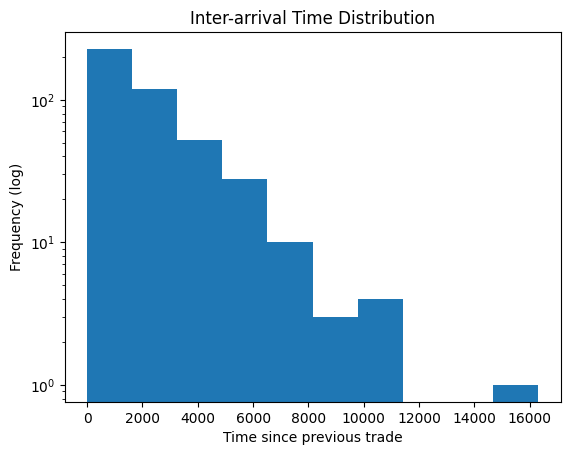

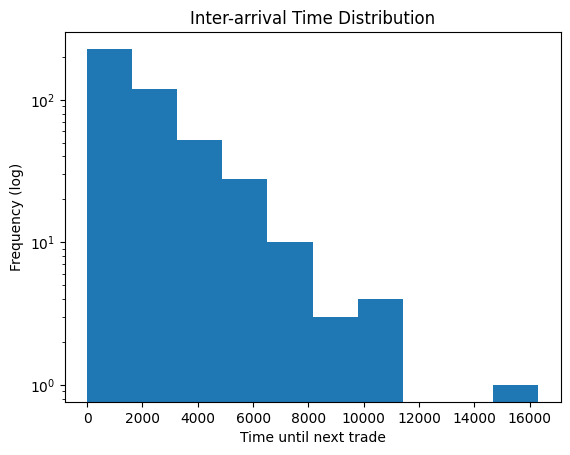

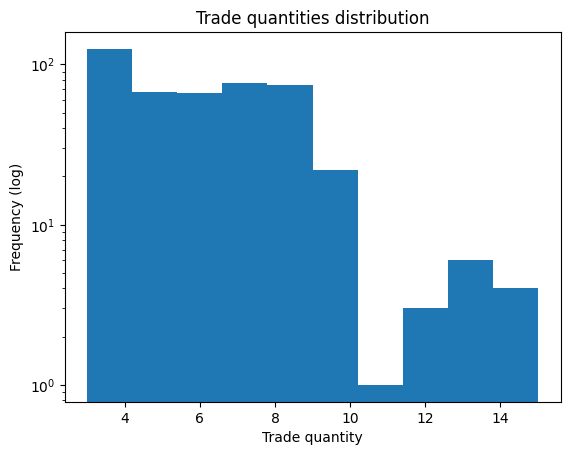

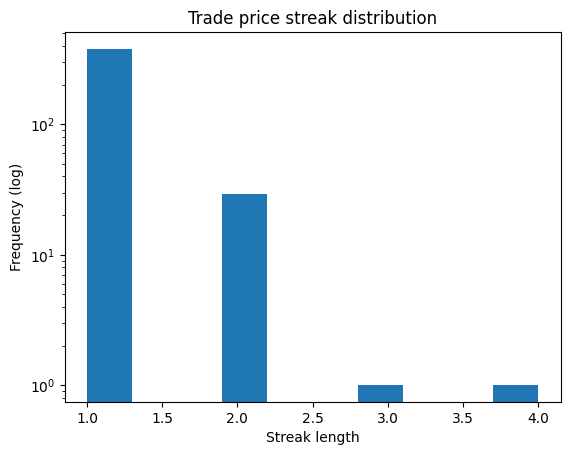

In [11]:
display_plots(plots)

# Mean Reversion Analysis

In [12]:
mean_reversion_results: t.Final[MeanReversionTestResults] = run_mean_reversion_test(
    orderbook_features_data, "mid_price"
)

regression_results: t.Final[SubsampledRegressionResults] = (
    mean_reversion_results.regression_results
)
adf_result: t.Final[ADFResult] = mean_reversion_results.adf_result
hurst_exponents: t.Final[tuple[np.float64, np.float64, np.float64]] = (
    mean_reversion_results.hurst_exponents
)

In [13]:
regression_results.print_summary()


lag_none
midprice (0 skips) is showing signs of mean reversion

lag_5
midprice (5 skips) is showing signs of mean reversion

lag_10
midprice (10 skips) is showing signs of mean reversion


In [14]:
adf_result

ADFResult(feature='mid_price', p_val=0.007342192260626399)

In [15]:
hurst_exponents

(np.float64(0.4275782019917811),
 np.float64(0.3899494490780619),
 np.float64(0.38589613043375365))